# 06 - Structured notes

Objectif: construire des notes structurees par composition obligation + options, analyser leurs payoffs et comparer leurs prix.

## Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.factory.structured_note_factory import StructuredNoteFactory
from src.market.market_data import MarketData
from src.models.black_scholes import BlackScholesModel
from src.models.discounting_model import DiscountingModel
from src.products.structured_note import (
    CapitalProtectedNote,
    CappedCapitalProtectedNote,
    ReverseConvertible,
)

## Build products

In [2]:
cpn = CapitalProtectedNote(
    product_id="CPN-1",
    notional=100.0,
    maturity=1.0,
    spot_reference=100.0,
    participation_rate=1.0,
)

ccpn = CappedCapitalProtectedNote(
    product_id="CCPN-1",
    notional=100.0,
    maturity=1.0,
    spot_reference=100.0,
    participation_rate=1.0,
    cap_level=1.2,
)

rc = ReverseConvertible(
    product_id="RC-1",
    notional=100.0,
    maturity=1.0,
    spot_reference=100.0,
    coupon_rate=0.10,
)

notes = {
    "capital_protected": cpn,
    "capped_capital_protected": ccpn,
    "reverse_convertible": rc,
}

pd.DataFrame([
    {"note": name, "legs": len(note.decomposition())}
    for name, note in notes.items()
])

,note,legs
0,capital_protected,2
1,capped_capital_protected,3
2,reverse_convertible,2


## Decomposition into elementary legs

In [3]:
decomposition_rows = []
for note_name, note in notes.items():
    for leg in note.decomposition():
        decomposition_rows.append(
            {
                "note": note_name,
                "label": leg.label,
                "leg_type": type(leg.product).__name__,
                "quantity": leg.quantity,
            }
        )

pd.DataFrame(decomposition_rows)

,note,label,leg_type,quantity
0,capital_protected,capital_protection_bond,ZeroCouponBond,1.0
1,capital_protected,upside_call,VanillaOption,1.0
2,capped_capital_protected,capital_protection_bond,ZeroCouponBond,1.0
3,capped_capital_protected,long_call_k1,VanillaOption,1.0
4,capped_capital_protected,short_call_k2,VanillaOption,-1.0
5,reverse_convertible,enhanced_coupon_bond,ZeroCouponBond,1.0
6,reverse_convertible,short_put,VanillaOption,-1.0


## Payoff scenarios at maturity

In [4]:
spot_grid = np.linspace(60.0, 150.0, 220)
payoffs = pd.DataFrame({"spot": spot_grid})

for name, note in notes.items():
    payoffs[name] = [note.payoff(spot) for spot in spot_grid]

payoffs.head()

,spot,capital_protected,capped_capital_protected,reverse_convertible
0,60.000000,100.0,100.0,70.000000
1,60.410959,100.0,100.0,70.410959
2,60.821918,100.0,100.0,70.821918
3,61.232877,100.0,100.0,71.232877
4,61.643836,100.0,100.0,71.643836


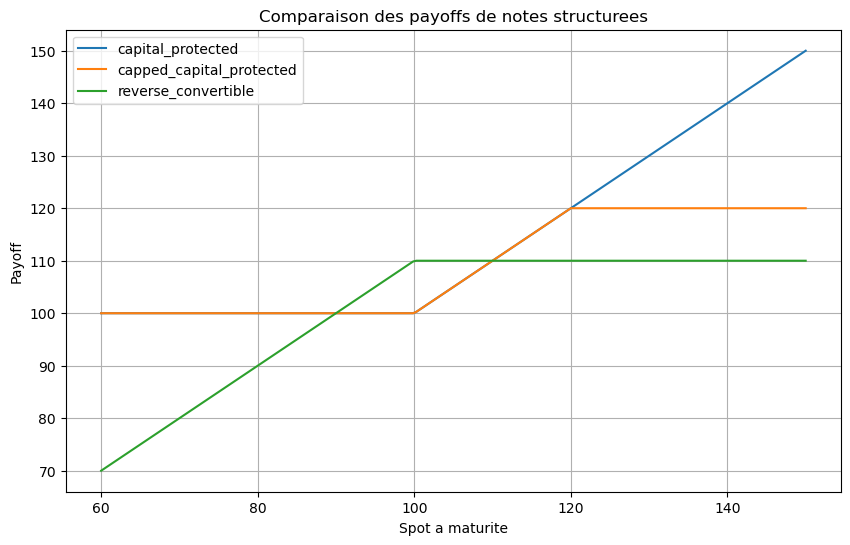

In [5]:
plt.figure(figsize=(10, 6))
for name in notes:
    plt.plot(payoffs["spot"], payoffs[name], label=name)
plt.xlabel("Spot a maturite")
plt.ylabel("Payoff")
plt.title("Comparaison des payoffs de notes structurees")
plt.grid(True)
plt.legend()
plt.show()

## Pricing comparison and decomposition consistency

In [6]:
bs_model = BlackScholesModel()
discount_model = DiscountingModel(rate=0.03)
market_data = MarketData(spot=100.0, rate=0.03, volatility=0.20, dividend_yield=0.0)

pricing_rows = []
for name, note in notes.items():
    direct = note.price(bs_model, discount_model, market_data)
    sum_of_legs = 0.0
    for leg in note.decomposition():
        if hasattr(leg.product, "option_type"):
            leg_price = bs_model.price(leg.product, market_data)
        else:
            leg_price = discount_model.price(leg.product, market_data)
        sum_of_legs += leg.quantity * leg_price

    pricing_rows.append(
        {
            "note": name,
            "price": direct,
            "sum_of_legs": sum_of_legs,
            "difference": direct - sum_of_legs,
        }
    )

pd.DataFrame(pricing_rows)

,note,price,sum_of_legs,difference
0,capital_protected,106.457957,106.457957,0.0
1,capped_capital_protected,103.691399,103.691399,0.0
2,reverse_convertible,100.291052,100.291052,0.0


## Factory mapping from inventory rows

In [7]:
inventory_rows = pd.DataFrame(
    [
        {
            "product_id": "SN-CPN",
            "product_type": "capital protected note",
            "quantity": 100.0,
            "participation_rate": 0.9,
            "time_to_maturity_years": 1.0,
        },
        {
            "product_id": "SN-CCPN",
            "product_type": "capped capital protected note",
            "quantity": 100.0,
            "participation_rate": 0.8,
            "cap": 1.25,
            "time_to_maturity_years": 1.0,
        },
        {
            "product_id": "SN-RC",
            "product_type": "reverse convertible",
            "quantity": 100.0,
            "coupon_rate": 0.12,
            "time_to_maturity_years": 1.0,
        },
    ]
)

factory = StructuredNoteFactory.with_defaults()
built_products = factory.build_many(inventory_rows, spot_reference=100.0)

pd.DataFrame(
    {
        "product_id": [p.product_id for p in built_products],
        "class": [type(p).__name__ for p in built_products],
    }
)

,product_id,class
0,SN-CPN,CapitalProtectedNote
1,SN-CCPN,CappedCapitalProtectedNote
2,SN-RC,ReverseConvertible
